# Entrenamiento DQN + Doble Recompensa - Interseccion Simple (Weibull)

Deep Q-Network (DQN) con `stable-baselines3`. Red neuronal MLP procesa estado continuo.

Configuracion:
- 72,000 timesteps, num_seconds=6000
- Recompensa: -(1.0*cola + 0.1*diff_espera) (estacionaria)
- Entorno unico con **libsumo** (~8x mas rapido que traci puro)
- CheckpointCallback guarda modelo cada 18000 steps
- Red [128, 128] para estados continuos

In [1]:
import os
import sys

try:
    import libsumo
    print("libsumo OK")
except ImportError:
    print("ADVERTENCIA: libsumo no encontrado. Instalar con: pip install libsumo")
    print("Usando traci puro (mas lento)")
    os.environ.pop("LIBSUMO_AS_TRACI", None)

import traci
print(f"traci: {traci.__file__}")

libsumo OK
traci: /home/santiago/Documentos/Tesis/.venv/lib/python3.14/site-packages/traci/__init__.py


In [2]:
# Verificar conexion
import traci

print("Sistema listo para simulacion")

Sistema listo para simulacion


In [3]:
import argparse
import pandas as pd
import sys
import numpy as np
import torch
torch._dynamo.config.suppress_errors = True

import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt

from sumo_rl import SumoEnvironment
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback

In [4]:
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)


class RewardTracker:
    """Track previous waiting time to compute difference (stationary reward)."""
    def __init__(self):
        self.prev_waiting = 0.0

    def reset(self):
        self.prev_waiting = 0.0

    def recompensa_combinada(self, ts):
        """Cola actual + diff de espera (estacionario)."""
        cola = ts.get_total_queued()
        espera_actual = sum(ts.get_accumulated_waiting_time_per_lane())
        diff_espera = max(0, espera_actual - self.prev_waiting)
        self.prev_waiting = espera_actual
        return -(1.0 * cola + 0.1 * diff_espera)

reward_tracker = RewardTracker()


class EarlyStopWrapper(gym.Wrapper):
    """Trunca el episodio cuando la red se vacía."""
    def __init__(self, env, tracker=None):
        super().__init__(env)
        self.tracker = tracker

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if self.env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            truncated = True
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        if self.tracker:
            self.tracker.reset()
        return self.env.reset(**kwargs)

In [5]:
NET = os.path.join("..", "Simple_Intersection.net.xml")
ROU = os.path.join("..", "Distribuciones", "loja_intersection_weibull.rou.xml")
OUT_FOLDER = "resultados"

os.makedirs(OUT_FOLDER, exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "mejores_pesos"), exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "logs"), exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "ultimo_pesos"), exist_ok=True)

print("NET existe:", os.path.exists(NET))
print("ROU existe:", os.path.exists(ROU))

NET existe: True
ROU existe: True


In [6]:
def get_args():
    prs = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter,
                                  description="""DQN Single-Intersection (Doble Recompensa)""")
    prs.add_argument("-route", dest="route", type=str, default=ROU)
    prs.add_argument("-net", dest="net", type=str, default=NET)
    prs.add_argument("-gui", action="store_true", default=False)
    prs.add_argument("-total_timesteps", dest="total_timesteps", type=int, default=72000)
    prs.add_argument("-num_seconds", dest="num_seconds", type=int, default=100000)
    prs.add_argument("-lr", dest="lr", type=float, default=1e-4)
    prs.add_argument("-buffer_size", dest="buffer_size", type=int, default=100000)
    prs.add_argument("-learning_starts", dest="learning_starts", type=int, default=5000)
    prs.add_argument("-batch_size", dest="batch_size", type=int, default=128)
    prs.add_argument("-target_update", dest="target_update", type=int, default=2000)
    prs.add_argument("-exploration_fraction", dest="exploration_fraction", type=float, default=0.8)
    prs.add_argument("-exploration_final_eps", dest="exploration_final_eps", type=float, default=0.05)
    return prs.parse_args(args=[])

In [7]:
args = get_args()

import sys as _sys
import os as _os
_old_stderr = _sys.stderr
_sys.stderr = open(_os.devnull, 'w')

env_train = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name="temp",
    single_agent=True,
    use_gui=args.gui,
    num_seconds=args.num_seconds,
    reward_fn=reward_tracker.recompensa_combinada,
    time_to_teleport=-1,
    additional_sumo_cmd="-W --no-step-log"
)

_sys.stderr = _old_stderr

env_train = EarlyStopWrapper(env_train, tracker=reward_tracker)

model = DQN(
    "MlpPolicy",
    env_train,
    learning_rate=args.lr,
    buffer_size=args.buffer_size,
    learning_starts=args.learning_starts,
    batch_size=args.batch_size,
    gamma=0.99,
    target_update_interval=args.target_update,
    exploration_fraction=args.exploration_fraction,
    exploration_final_eps=args.exploration_final_eps,
    policy_kwargs=dict(net_arch=[128, 128]),
    verbose=0
)

# Guardar checkpoint cada 18000 steps (1/4 del total)
checkpoint_cb = CheckpointCallback(
    save_freq=18000,
    save_path=os.path.join(OUT_FOLDER, 'mejores_pesos'),
    name_prefix='dqn_checkpoint'
)

import time as time_mod
from stable_baselines3.common.callbacks import BaseCallback

class ProgressCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.start_time = time_mod.time()
        self.episode_count = 0
        self.rewards = []
    
    def _on_step(self):
        infos = self.locals.get('infos', [{}])
        if isinstance(infos, list) and len(infos) > 0:
            info = infos[0]
            if 'episode' in info:
                self.episode_count += 1
                ep_reward = info['episode'].get('r', 0)
                ep_len = info['episode'].get('l', 0)
                elapsed = time_mod.time() - self.start_time
                self.rewards.append(ep_reward)
                print(f"  Ep {self.episode_count:3d} | Rec: {ep_reward:10.2f} | Steps: {ep_len:5d} | Time: {elapsed:.0f}s")
        return True

try:
    print("Iniciando entrenamiento DQN con libsumo...")
    progress_cb = ProgressCallback()
    model.learn(total_timesteps=args.total_timesteps, callback=[checkpoint_cb, progress_cb])

    model.save(os.path.join(OUT_FOLDER, "ultimo_pesos", "dqn_ultimo"))
    model.save(os.path.join(OUT_FOLDER, "mejores_pesos", "best_model"))
    print(f"\nModelos guardados en {OUT_FOLDER}")
finally:
    env_train.close()
print("Entrenamiento finalizado.")

# Limpiar CSVs temporales de entrenamiento
import glob as _glob
for _f in _glob.glob("temp_*.csv"):
    os.remove(_f)


 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
Iniciando entrenamiento DQN con libsumo...
 Retrying in 1 seconds
 Retrying in 1 seconds
  Ep   1 | Rec:  -17966.20 | Steps:   762 | Time: 17s
 Retrying in 1 seconds
  Ep   2 | Rec:  -19920.70 | Steps:   780 | Time: 33s
 Retrying in 1 seconds
  Ep   3 | Rec:  -18166.70 | Steps:   764 | Time: 49s
 Retrying in 1 seconds
  Ep   4 | Rec:  -17408.90 | Steps:   778 | Time: 66s
 Retrying in 1 seconds
  Ep   5 | Rec:  -18491.40 | Steps:   768 | Time: 82s
 Retrying in 1 seconds
  Ep   6 | Rec:  -20378.50 | Steps:   820 | Time: 100s
 Retrying in 1 seconds
  Ep   7 | Rec:  -21901.30 | Steps:   803 | Time: 119s
 Retrying in 1 seconds
  Ep   8 | Rec:  -19828.10 | Steps:   791 | Time: 138s
 Retrying in 1 seconds
  Ep   9 | Rec:  -20957.20 | Steps:   838 | Time: 158s
 Retrying in 1 seconds
  Ep  10 | Rec:  -19532.40 | Steps:   766 | Time: 177s
 Retrying in 1 seconds
  Ep  11 | Rec:  -17039

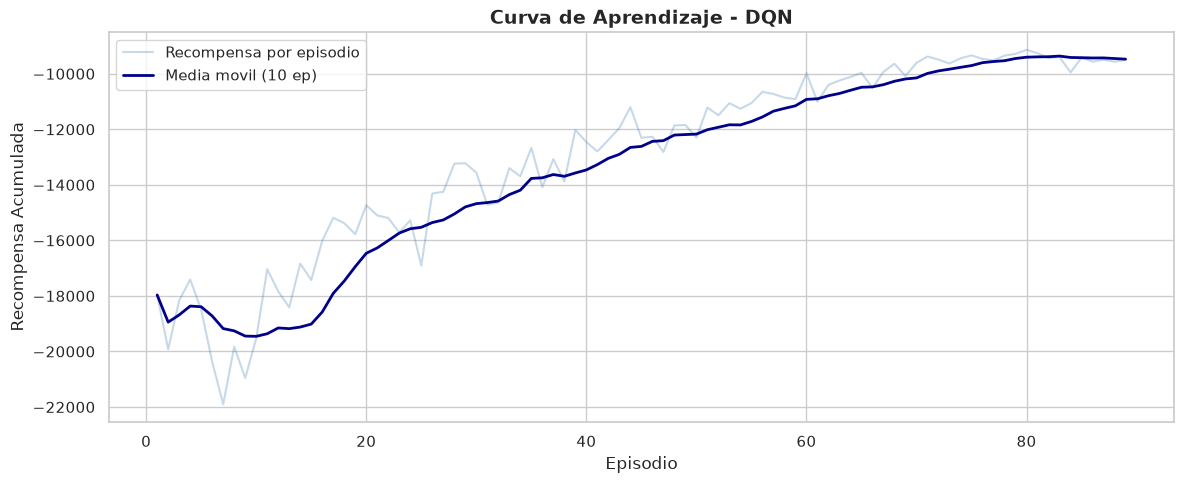

Episodios: 89
Mejor recompensa: -9137.70
Recompensa final (ultimos 10): -9472.69


In [8]:
# Curva de Aprendizaje
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 5))

rewards = progress_cb.rewards
episodes = range(1, len(rewards) + 1)
plt.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Recompensa por episodio')

# Media movil (ventana de 10 episodios)
window = min(10, len(rewards))
media_movil = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
plt.plot(episodes, media_movil, color='darkblue', linewidth=2, label=f'Media movil ({window} ep)')

plt.title('Curva de Aprendizaje - DQN', fontsize=14, fontweight='bold')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Episodios: {len(rewards)}")
print(f"Mejor recompensa: {max(rewards):.2f}")
print(f"Recompensa final (ultimos 10): {pd.Series(rewards).tail(10).mean():.2f}")

In [7]:
import glob

# Listar checkpoints guardados
checkpoints = sorted(glob.glob(os.path.join(OUT_FOLDER, 'mejores_pesos', 'dqn_checkpoint_*.zip')))
print(f"Checkpoints guardados: {len(checkpoints)}")
for ck in checkpoints:
    print(f"  {ck}")

ultimo = os.path.join(OUT_FOLDER, 'ultimo_pesos', 'dqn_ultimo.zip')
mejor = os.path.join(OUT_FOLDER, 'mejores_pesos', 'best_model.zip')
if os.path.exists(ultimo):
    print(f"\nUltimo modelo: {ultimo}")
if os.path.exists(mejor):
    print(f"Mejor modelo: {mejor}")

Checkpoints guardados: 4
  resultados/mejores_pesos/dqn_checkpoint_18000_steps.zip
  resultados/mejores_pesos/dqn_checkpoint_36000_steps.zip
  resultados/mejores_pesos/dqn_checkpoint_54000_steps.zip
  resultados/mejores_pesos/dqn_checkpoint_72000_steps.zip

Ultimo modelo: resultados/ultimo_pesos/dqn_ultimo.zip
Mejor modelo: resultados/mejores_pesos/best_model.zip


In [9]:
print("Cargando mejor modelo...")
model = DQN.load(os.path.join(OUT_FOLDER, "ultimo_pesos", "dqn_ultimo"))

args = get_args()

env_eval = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name=os.path.join(OUT_FOLDER, 'evaluacion_final'),
    single_agent=True,
    use_gui=True,
    num_seconds=args.num_seconds,
    time_to_teleport=-1,
    additional_sumo_cmd=f"-W --no-step-log --tripinfo-output {os.path.join(OUT_FOLDER, 'tripinfo.xml')}"
)

obs, _ = env_eval.reset()
try:
    done = False
    datos_recolectados = []

    print("Ejecutando evaluacion...")

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_eval.step(action)
        datos_recolectados.append(info)

        if env_eval.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            tiempo_final = env_eval.unwrapped.sim_step
            print(f"Evaluacion completada. Red vaciada en {tiempo_final:.1f}s")
            break

        done = terminated or truncated

finally:
    env_eval.close()

df_metricas = pd.DataFrame(datos_recolectados)
ruta_csv = os.path.join(OUT_FOLDER, "metricas.csv")
os.makedirs(OUT_FOLDER, exist_ok=True)
df_metricas.to_csv(ruta_csv, index=False)

print(f"CSV exportado: {ruta_csv}")
print(f"XML generado: {os.path.join(OUT_FOLDER, 'tripinfo.xml')}")

Cargando mejor modelo...
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 0ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Ejecutando evaluacion...
Evaluacion completada. Red vaciada en 4175.0s
CSV exportado: resultados/dataset_sumo.csv
XML generado: resultados/tripinfo_final.xml


In [10]:
df_metricas = pd.read_csv(os.path.join(OUT_FOLDER, "metricas.csv"))
print(f"Registros cargados: {len(df_metricas)}")

Registros cargados: 835


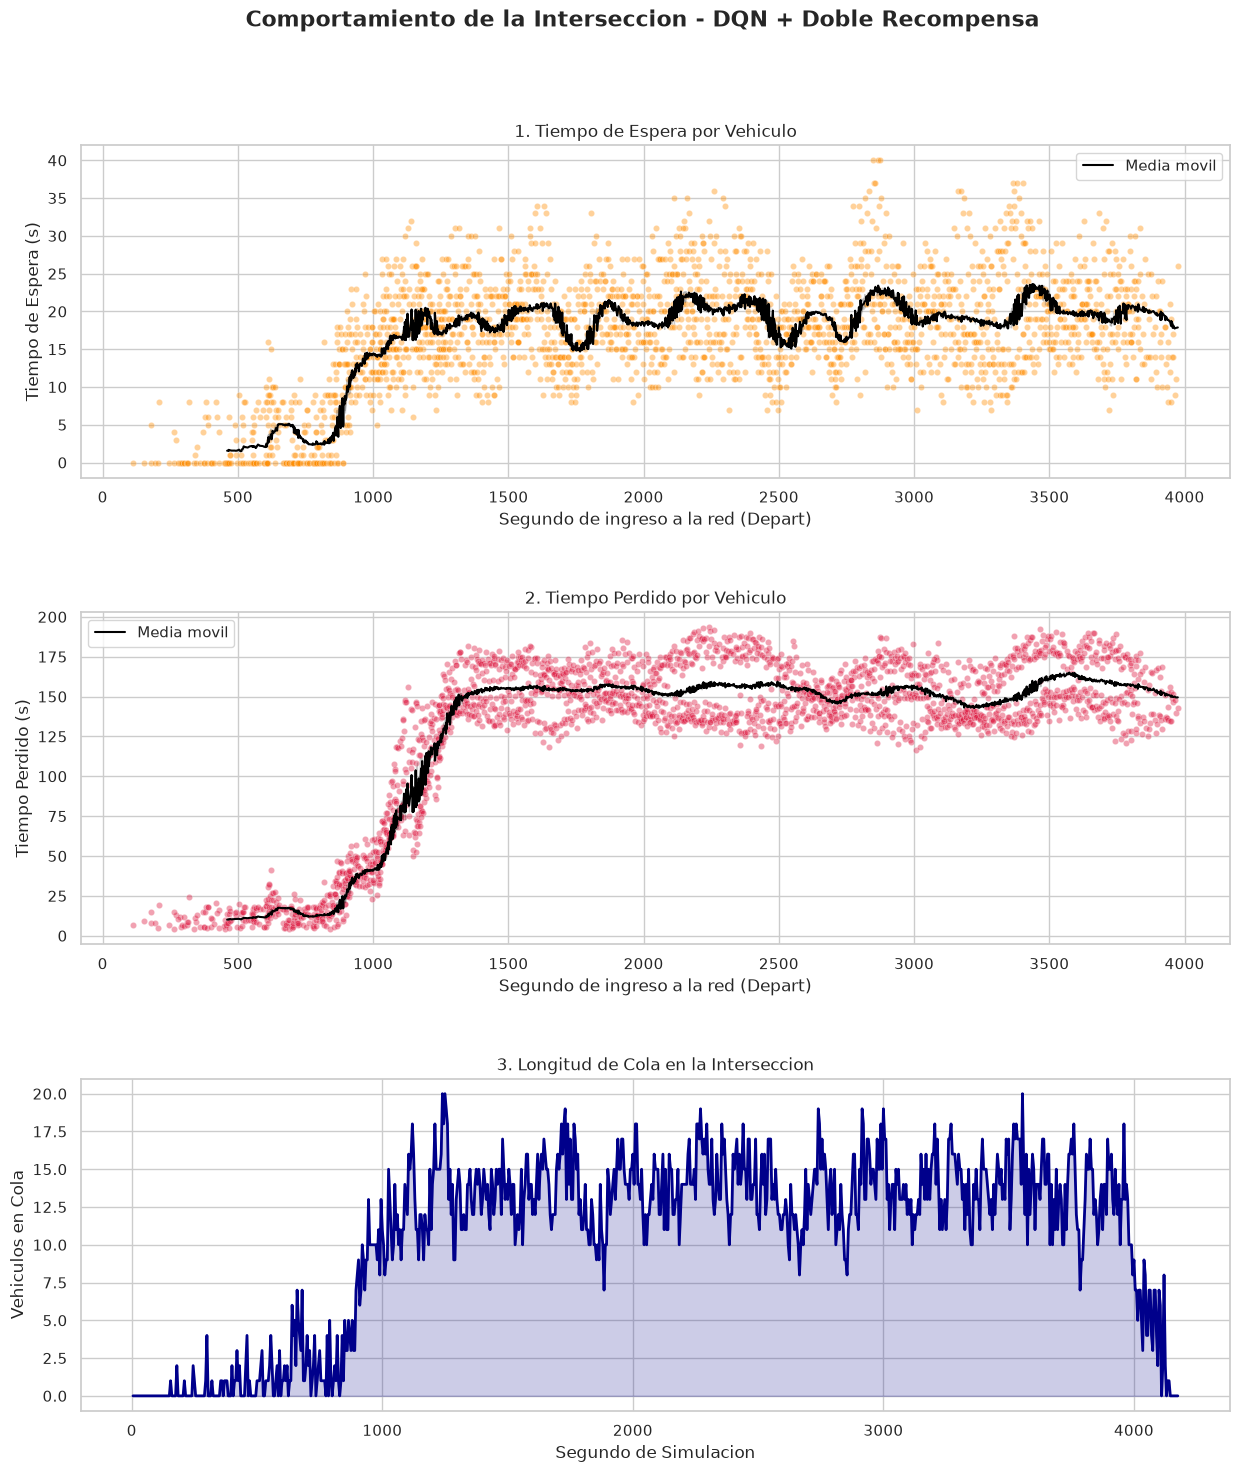

In [11]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

ruta_xml = os.path.join(OUT_FOLDER, "tripinfo.xml")
df_trips = pd.read_xml(ruta_xml)

for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0)
fig.suptitle('Comportamiento de la Interseccion - DQN + Doble Recompensa', fontsize=16, fontweight='bold', y=1.02)

sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Media movil', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehiculo")
axs[0].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Media movil', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehiculo")
axs[1].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

axs[2].plot(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', linewidth=2)
axs[2].fill_between(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', alpha=0.2)
axs[2].set_title("3. Longitud de Cola en la Interseccion")
axs[2].set_xlabel("Segundo de Simulacion")
axs[2].set_ylabel("Vehiculos en Cola")

plt.show()

In [17]:
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()
promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()
velocidad_media = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)
cola_promedio = df_metricas['system_total_stopped'].mean()
cola_maxima = df_metricas['system_total_stopped'].max()

print("=" * 50)
print("  REPORTE DE METRICAS: DQN + DOBLE RECOMPENSA")
print("=" * 50)
print("\n--- Rendimiento General ---")
print(f"Total de vehiculos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media:.2f} km/h")

print("\n--- Demora Vehicular (Tripinfo) ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MAXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MAXIMO         : {maximo_perdido:.2f} s")

print("\n--- Ocupacion de la Interseccion (TraCI) ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehiculos")
print(f"Longitud de cola MAXIMA       : {cola_maxima} vehiculos")
print("=" * 50)
display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  REPORTE DE METRICAS: DQN + DOBLE RECOMPENSA

--- Rendimiento General ---
Total de vehiculos procesados : 2418
Velocidad promedio del sistema: 15.36 km/h

--- Demora Vehicular (Tripinfo) ---
Tiempo de espera promedio     : 16.74 s
Tiempo de espera MAXIMO       : 39.00 s
Tiempo perdido promedio       : 123.44 s
Tiempo perdido MAXIMO         : 200.69 s

--- Ocupacion de la Interseccion (TraCI) ---
Longitud de cola promedio     : 10.21 vehiculos
Longitud de cola MAXIMA       : 20 vehiculos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,49.0,0.0,5.11
1,veh_1,154.0,54.0,0.0,9.40
2,veh_2,179.0,53.0,0.0,7.19
3,veh_3,179.0,58.0,5.0,14.17
4,veh_4,195.0,52.0,0.0,6.24
